Let's load our saved data first, fresh, to confirm Notebook 2 is self-contained:

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rfm = pd.read_csv(r'../Data/rfm.csv')
feature_scaled_df = pd.read_csv(r'../Data/feature_scaled_df.csv', index_col='Customer ID')

Let's verify everything is intact

In [3]:
print(rfm.shape)
print(feature_scaled_df.shape)

(5878, 6)
(5878, 3)


Okay, everything is as it is.

---

## Principal component Analysis (PCA)

In [4]:
from sklearn.decomposition import PCA

In [5]:
pca = PCA(n_components=2)

In [6]:
pca_result = pca.fit_transform(feature_scaled_df)

Let's check how much veriance our model PCA components capture:

In [7]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.74725232 0.20325631]
0.9505086343884523


`[0.74725232, 0.20325631]` — PC1 captures 74.7% of the variance, PC2 captures 20.3%. Two numbers because we asked for `n_components=2`.

`.sum()` — just adding those two numbers together: `0.747 + 0.203 = 0.9505`. This tells us the combined amount of information your 2D projection retains out of the original 3 features. 95.05% retained means only ~5% of the original variance was "lost" by compressing from 3 dimensions down to 2,meaning almost nothing meaningful is lost.

**Next:** Let's visualize it:

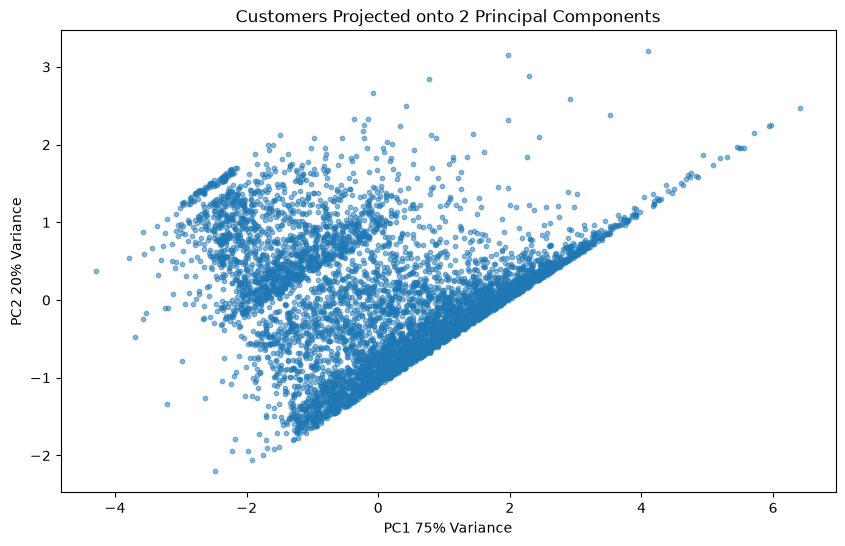

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('Customers Projected onto 2 Principal Components')
plt.show()

**What the shape tells us:**

* No clean, separated blobs. This is one continuous, dense cloud that thins out as it spreads — not 3-4 visually distinct islands with empty space  between them. That's an honest, important finding: our customer base doesn't naturally split into obviously separate groups. Customer behavior here is more of a spectrum (gradually more engaged → gradually less engaged) than distinct categories.

* The triangular/fan shape, densest near the bottom-left, thinning as it goes up and right. Most customers cluster tightly in the lower-left (low PC1, low-to-mid PC2) — this is our "typical" customer mass. As we move up and to the right, points get sparser — these are increasingly extreme/unusual customers.

* The scattered outlier points far to the right (PC1 ≈ 4-6.5) and the ones near the top (PC2 ≈ 2.5-3.2). These are very likely our wholesale-pattern customers from earlier — remember our CustomerID 16446, 18102, 14646? High Monetary/Frequency pulls them far from the main cloud along these axes. we're seeing the exact outlier behavior we investigated earlier, now visually confirmed.

**Why this matters for what comes next:**

Given there's no obvious visual separation into clean groups, don't expect K-Means to find some clean, obvious answer that jumps out at us either. The **elbow method** and **silhouette score** will likely show a soft signal, not a dramatic one. 

This is also exactly the kind of shape where DBSCAN's behavior will look meaningfully different from K-Means: DBSCAN, being density-based, may treat that dense lower-left mass as one or two clusters and correctly flag the sparse scattered points on the right/top as noise — while K-Means, forced to partition everything into exactly k groups regardless of density, will carve arbitrary boundaries through this continuous cloud, potentially even splitting the dense mass into artificial sub-groups just to satisfy k.

---

## K-Means clustering

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [10]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(feature_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(feature_scaled_df, labels))

**Note:** *`n_init=10` means, K-Means is run 10 separate times with different random starting centroids, and sklearn keeps the best result (lowest inertia). This guards against a single unlucky random start giving us a misleadingly bad result.*

Now let's plot both — elbow curve and silhouette curve, side by side, so we can compare where they agree or disagree.

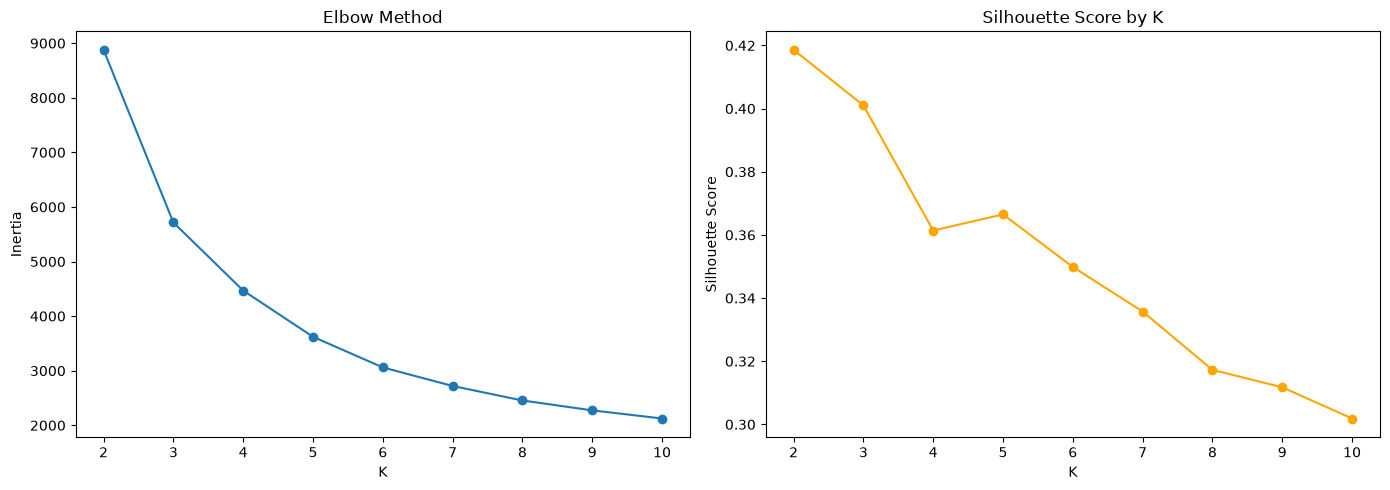

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

**Elbow plot:**\
The sharpest drop is from k=2→3 (8900→5700), and a second, smaller bend around k=3→4 (5700 → 4450). After k=4, the curve flattens into a long, gentle decline with no more real bends, each additional cluster buys us less and less.

**Silhouette plot:**\
Highest score is at k=2 (0.418), drops at k=3 (0.401), dips further at k=4 (0.361), then a small local bump at k=5 (0.367), before declining steadily onward. k=2 is mathematically the "best" by this metric, but k=2 is also almost always too coarse to be useful for customer segmentation, splitting our entire base into just 2 groups rarely gives a business anything actionable ("high value" vs "everyone else" is barely a segmentation).

**Where they agree, which is what actually matters:**\
Both plots show k=2 and k=3 as strong performers, with k=4 as the point where the elbow visibly flattens and silhouette takes its biggest drop after k=3. That convergence — elbow bending around 3-4, silhouette favoring 2-3 with a real dip starting at 4 — points to k=3 or k=4 as our defensible range, not k=2 (too coarse to be useful) and not the higher values (silhouette keeps declining, offering no benefit).

**Final decision**\
Let's go with **`k=4`** beacuse silhouette score technically peaks at `k=2`, but this offers limited business value. `k=4` is being selected as the point where the elbow curve flattens and silhouette score remains reasonable (0.361), balancing statistical fit against interpretability, a common tradeoff in real-world clustering.

In [33]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(feature_scaled_df)

Let's check how many customers landed in each of the 4 clusters:

In [34]:
np.unique(kmeans_labels, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([1638, 1384, 1891,  965]))

this is a genuinely healthy split
* Cluster 0: 1,638 customers
* Cluster 1: 1,384 customers
* Cluster 2: 1,891 customers
* Cluster 3: 965 customers

No cluster is empty, none is a tiny handful (like 5 or 20 customers), and none dominates by absorbing 90%+ of the data. The largest (1,891) is only about 2x the smallest (965), which is a reasonably balanced split across all four groups out of ~5,878 total customers.

**Next:** Let's plot the clusters on our existing PCA scatter:

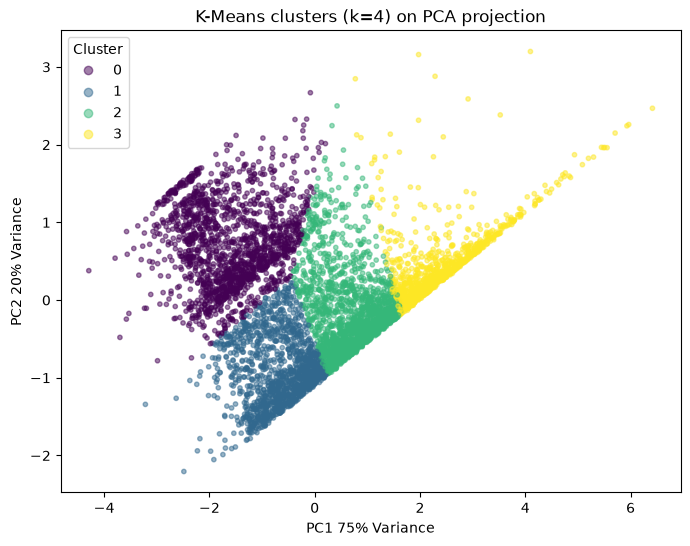

In [56]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('K-Means clusters (k=4) on PCA projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

**NOTE:**\
*`c=kmeans_labels` - colors each point according to which cluster it was assigned to, instead of one flat color*\
*`cmap='viridis'` - a colormap that gives each of the 4 clusters a visually distinct color*\
*`scatter.legend_elements()` - automatically builds a legend mapping colors to cluster numbers, so we don't have to hardcode it*

K-Means separates clusters using straight-line boundaries (visible where cluster colors meet), but because the underlying PCA-projected data forms an irregular,\
fan-shaped cloud rather than distinct round groups, the resulting cluster regions appear as irregular wedges rather than clean, compact shapes.

---

## Hierarchical Clustering (Agglomerative)

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [45]:
linked = linkage(feature_scaled_df, method='ward')

Let's plot the dendogram

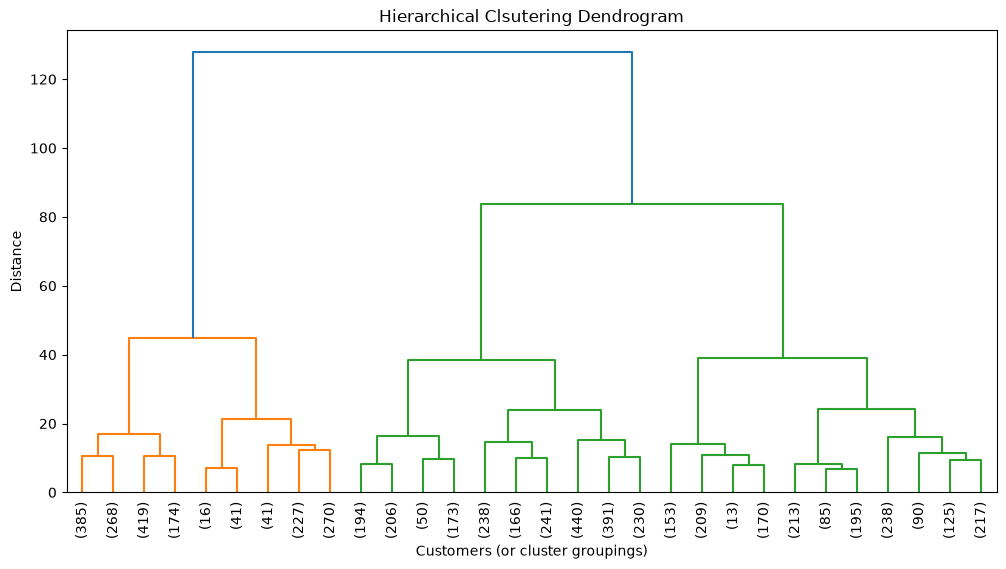

In [52]:
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.xlabel('Customers (or cluster groupings)')
plt.ylabel('Distance')
plt.title('Hierarchical Clsutering Dendrogram')
plt.show()

The dendrogram's largest gap suggests a 2-cluster split at the highest level, with meaningful sub-structure emerging around 3-4 clusters. This loosely supports the `k=4` choice from K-Means but doesn't uniquely confirm it — consistent with the earlier PCA/silhouette finding that customer behavior in this dataset is more continuous than sharply segmented.

**Next:** Let's cut the tree at `k=4` (to match K-Means for a fair comparison) and get actual cluster labels:

In [53]:
from scipy.cluster.hierarchy import fcluster

In [54]:
hier_labels = fcluster(linked, t=4, criterion='maxclust')

Let's check how many customers landed in each of the 4 clusters and visualize it as well:

(array([1, 2, 3, 4], dtype=int32), array([1246,  595, 2329, 1708]))


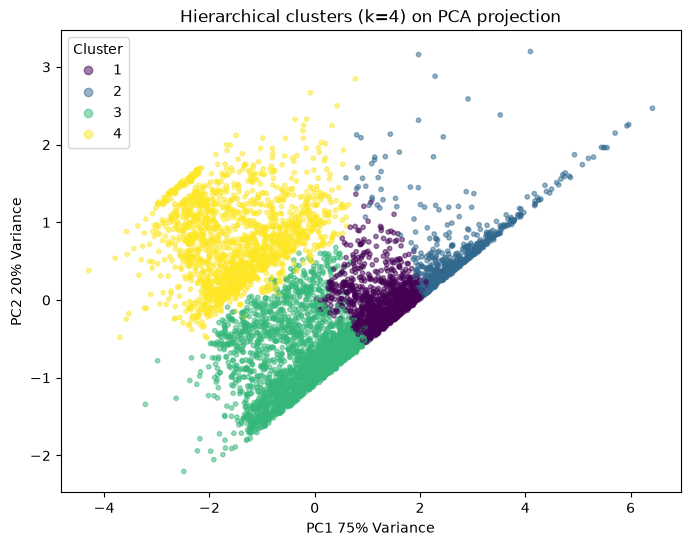

In [59]:
print(np.unique(hier_labels, return_counts=True))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=hier_labels, cmap='viridis', alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('Hierarchical clusters (k=4) on PCA projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

Hierarchical clustering (`Ward linkage`, `k=4`) produced a less balanced partition (*595 – 2329 customers per cluster*) than K-Means (*965 – 1891*),\
despite using the same `k`. 

The two algorithms disagree meaningfully on cluster boundaries — Hierarchical isolates a narrow, distinct cluster along the
high-Monetary/Frequency outlier tail (Cluster 2,595 customers), while K-Means distributed similar customers across a larger cluster. 

This suggests the 'right' number of clusters is less important than the algorithm's underlying assumptions about cluster shape and size, a key reason to compare multiple methods rather than trust one blindly.

**Next:** quantify the agreement directly, not just visually:

In [60]:
pd.crosstab(kmeans_labels, hier_labels)

col_0,1,2,3,4
row_0,,,,
0,0,0,63,1575
1,0,0,1382,2
2,869,8,884,130
3,377,587,0,1


**How to read this table:**\
rows = K-Means clusters (0-3), columns = Hierarchical clusters (1-4).\
Each cell = how many customers from a given K-Means cluster ended up in a given Hierarchical cluster.

**Where they agree strongly:**\
K-Means cluster 0 (1,638 total) → 1,575 went to Hierarchical cluster 4, only 63 elsewhere. 96% agreement.\
K-Means cluster 1 (1,384 total) → 1,382 went to Hierarchical cluster 3, only 2 elsewhere. Essentially 100% agreement.

**Final findings:**\
K-Means and Hierarchical clustering agree strongly on two segments (96-100% overlap) — likely representing genuinely distinct customer behavior. However, they diverge substantially on the remaining customers: K-Means' largest cluster (1,891 customers) was split across three different Hierarchical groups, indicating this segment sits in a genuinely ambiguous, continuous region of the behavior space rather than a well-defined cluster. This is consistent with the earlier PCA/silhouette findings that not all customer behavior separates cleanly into discrete categories.

---

## DBSCAN Clustering

#### The core idea:
Fundamentally different approach from the previous two: DBSCAN doesn't need `k` at all. Instead, it groups points based on density — a cluster is a region where points are packed closely together, separated by sparse regions from other clusters. Any point sitting in a sparse area with no dense neighborhood around it gets labeled as noise (`-1`), not forced into a cluster.

This is exactly the property missing from K-Means and Hierarchical — both were forced to assign our wholesale-pattern outliers (16446, 18102, etc.) into some cluster no matter what. DBSCAN can instead say: *"these points don't belong anywhere meaningful."*

## Plot K-Distance:
We're doing this to pick `eps`(epsilon) for DBSCAN; this is DBSCAN's version of the elbow method.

In [61]:
from sklearn.neighbors import NearestNeighbors

In [62]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)

`min_samples = 5` is the DBSCAN's parameter we decided on (using the `2 × number of features` heuristic, roughly). we're defining it here, before DBSCAN even shows up, because we need this exact number to build a k-distance plot that's actually relevant to the DBSCAN run we'll do later.

**Next:** `neighbors` will learn the structure of our data, building an internal index of where every customer sits,
so it can efficiently answer *"who's near this point"* later.

In [63]:
neighbors_fit = neighbors.fit(feature_scaled_df)

Let's extract `distances` (how far away each of those 5 neighbors is) and `indices` (which customers those neighbors actually are, by row position.)\
It'll be happening for each point in our dataset.

In [64]:
distances, indices = neighbors_fit.kneighbors(feature_scaled_df)

In [68]:
distances = np.sort(distances[:, -1])

Here, we're selecting only the last column, meaning the distance to the 5th (farthest of the 5) nearest neighbor, for every customer. This is deliberate: the distance to our farthest required neighbor is what tells us *whether a point has a dense-enough neighborhood*, if even our 5th neighbor is far away,
that point is sitting somewhere sparse.

**NOTE:** *this reassigns distances to a new 1D array, overwriting the original 2D version — fine here since we don't need the original shape anymore, but worth knowing if we wanted to reuse the original later.*

Finally, let's plot the k-distance:

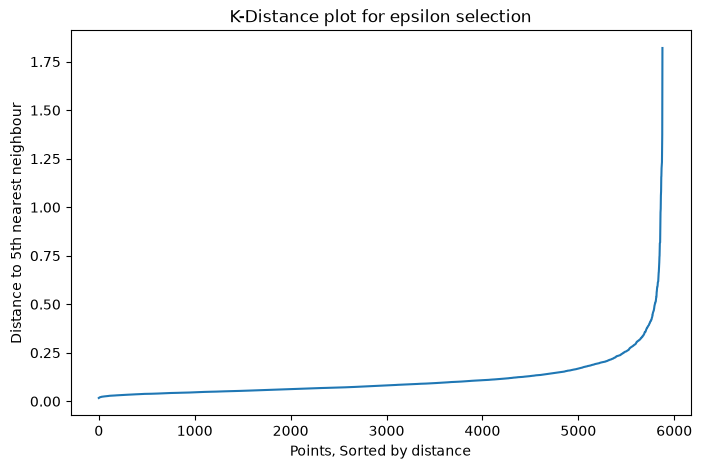

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points, Sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbour')
plt.title('K-Distance plot for epsilon selection')
plt.show()

**Picking eps:** The elbow is where the curve starts bending upward. Looking at this shape, the bend starts somewhere around 0.2-0.3 on the y-axis.

**Practical way to nail this down more precisely:** Let's zoom into just the tail end of the curve, where the actual bend happens:

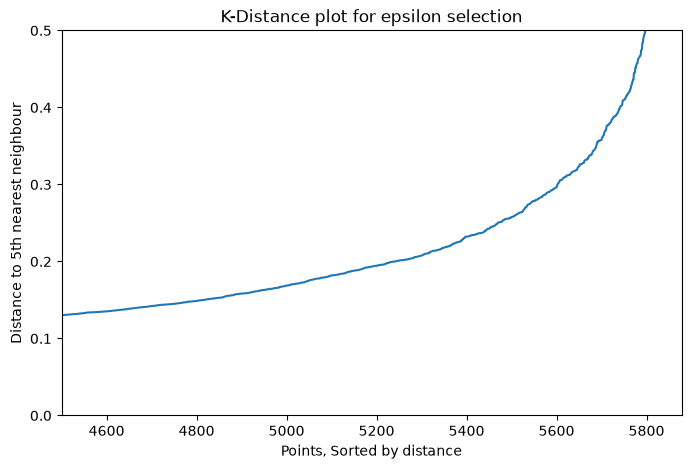

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points, Sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbour')
plt.title('K-Distance plot for epsilon selection')
plt.xlim(4500, 5878)
plt.ylim(0, 0.5)
plt.show()

It seems `eps=0.25` would be appropriate.

Finally, let's run DBSCAN:

In [76]:
from sklearn.cluster import DBSCAN

In [125]:
dbscan = DBSCAN(eps=0.33, min_samples=min_samples)

In [126]:
dbscan_labels = dbscan.fit_predict(feature_scaled_df)

Let's check how many customers landed in each of the 5 clusters:

**NOTE:** *DBSCAN uses -1 as the label for noise points*

In [127]:
print(np.unique(dbscan_labels, return_counts=True))

(array([-1,  0,  1,  2]), array([ 135, 3209, 1604,  930]))


**Note on cluster count:**\
DBSCAN converged on 3 clusters, not 4 (the number chosen for K-Means and Hierarchical). This is not a discrepancy to resolve — DBSCAN doesn't take a target cluster count as input; it discovers however many density-based clusters the data actually supports. The fact that it independently found 3 groups, while K-Means and Hierarchical were told to find 4, suggests the "true" structure may be closer to 3 well-separated behavioral groups plus a set of atypical outliers, rather than 4 evenly-weighted segments. This mismatch across algorithms is itself a meaningful finding, not a failure of any one method.

#### DBSCAN — Parameter Tuning

`min_samples` was set to 5 (≈ 2× number of features, a common heuristic), and `eps` was selected using a k-distance plot,\
then refined by testing several values directly:

| eps  | Clusters found | Noise points | Notes |
|------|-----------------|--------------|-------|
| 0.20 | 8 (0–7)         | 433          | Several clusters of 4–11 customers — noise fragmenting into tiny, meaningless groups |
| 0.25 | 7 (0–6)         | 273          | Still 3 tiny clusters (5–6 customers each) |
| 0.30 | 6 (0–5)         | 163          | Improving — down to 4 tiny clusters, but still fragmented |
| **0.33** | **3 (0–2)** | **135**      | **Clean result** — 3 substantial clusters (3,209 / 1,604 / 930), no fragments |

**Pattern observed:**\
As `eps` increases from 0.20 to 0.33, the small "phantom" clusters (4–11 customers) progressively disappear, merging into either a real cluster or the noise group, while total noise count steadily drops (433 → 273 → 163 → 135). This is expected DBSCAN behavior — too-small `eps` treats normal density variation as separate micro-clusters; increasing it gradually consolidates these into genuine structure.

**Final choice: `eps=0.33`.**\
First value tested that produces a small number of substantial, stable clusters with no fragment groups — the cleanest, most interpretable result in the sweep.

#### Let's plot `dbscan_labels` on PCA

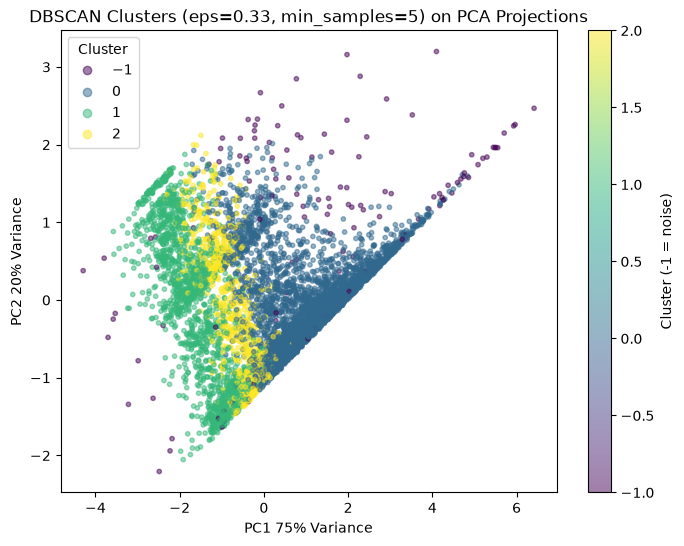

In [132]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.5, s=10)
plt.xlabel('PC1 75% Variance')
plt.ylabel('PC2 20% Variance')
plt.title('DBSCAN Clusters (eps=0.33, min_samples=5) on PCA Projections')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.show()

The DBSCAN cluster plot visually confirms the algorithm's core advantage: noise points (purple) are distributed along the entire periphery of the customer distribution — not just the high-Monetary tail, but low-density regions in every direction.

This contrasts sharply with K-Means and Hierarchical, both of which were forced to absorb these same edge customers into their nearest cluster regardless of how atypical their behavior actually was.

The 3 dense clusters found here sit in the compact core of customer behavior, with noise correctly representing the customers who don't fit any consistent pattern.

---

## UMAP